In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [ ]:
plt.rcParams.update({
    'font.size': 15,          # general font size
    'axes.titlesize': 15,     # title
    'axes.labelsize': 15,     # x and y labels
    'xtick.labelsize': 15,    # x tick labels
    'ytick.labelsize': 15,    # y tick labels
    'legend.fontsize': 12     # legend
})

cosine


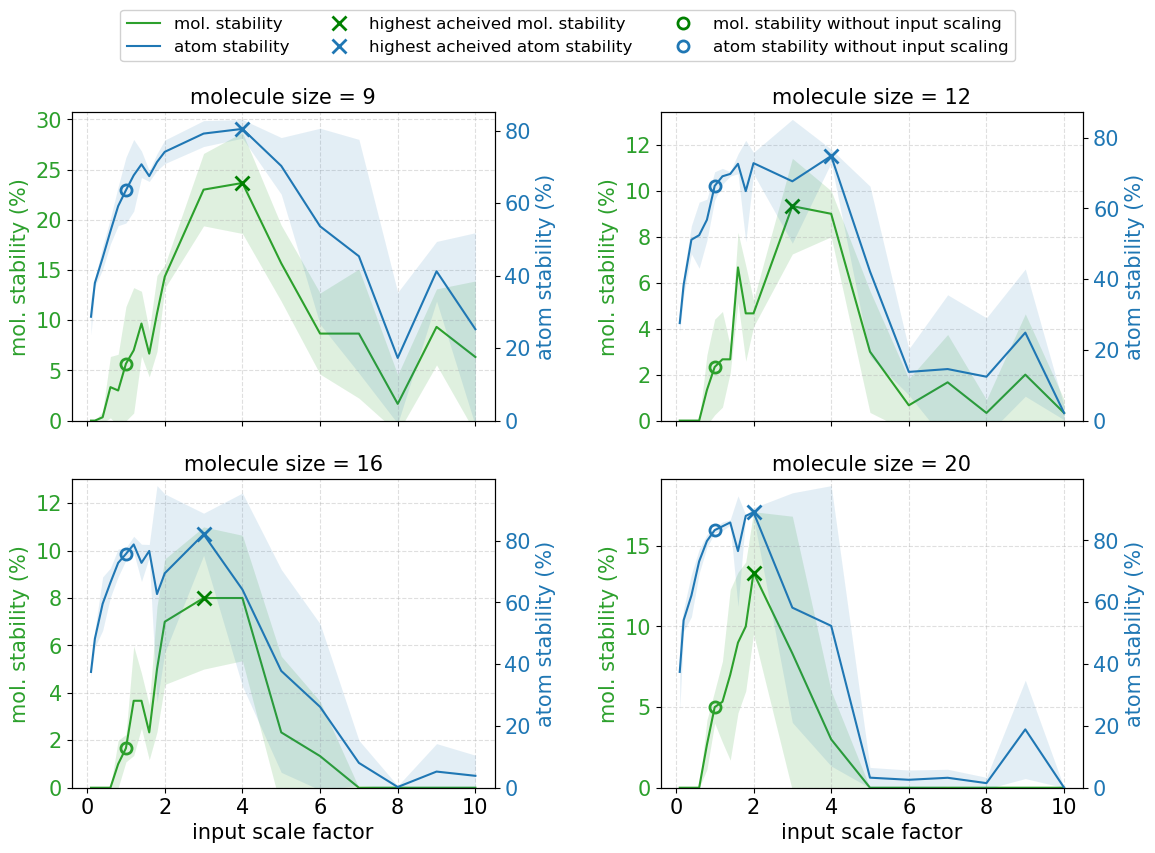

polynomial_2


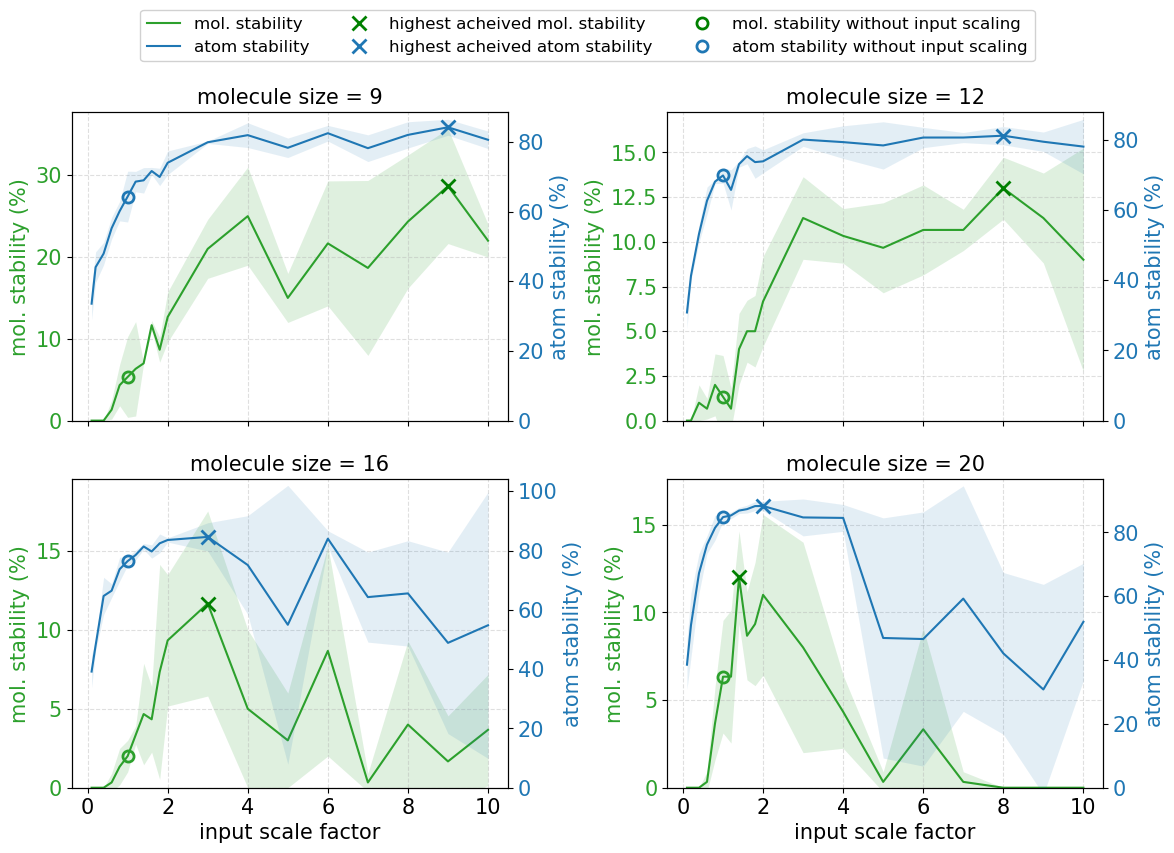

In [40]:
# Load CSV
df = pd.read_csv("input_scaling_evaluation_log_rq1.csv")  # replace with your actual CSV filename

# Group and compute mean + std across seeds
grouped = (
    df.groupby(["filter_n_atoms", "input_scale_factor", "diffusion_noise_schedule"])
    .agg(
        mol_mean = ("mol_stable", "mean"),
        mol_std  = ("mol_stable", "std"),
        atm_mean = ("atm_stable", "mean"),
        atm_std  = ("atm_stable", "std"),
    )
    .reset_index()
)

# Replace NaN std (e.g., single-seed groups) with 0 so shading doesn't break
grouped["mol_std"] = grouped["mol_std"].fillna(0.0)
grouped["atm_std"] = grouped["atm_std"].fillna(0.0)

mol_min, mol_max = grouped["mol_mean"].min(), grouped["mol_mean"].max()
atm_min, atm_max = grouped["atm_mean"].min(), grouped["atm_mean"].max()

noise_schedules = grouped["diffusion_noise_schedule"].unique()
filter_values = sorted(grouped["filter_n_atoms"].unique())

for noise_schedule, schedule_df in grouped.groupby("diffusion_noise_schedule"):
    print(noise_schedule)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()

    for i, n_atoms in enumerate(filter_values):
        ax_left = axes[i]
        sub_df = schedule_df[schedule_df["filter_n_atoms"] == n_atoms].copy()
        sub_df = sub_df.sort_values("input_scale_factor").reset_index(drop=True)
        if sub_df.empty:
            ax_left.set_visible(False)
            continue

        x = sub_df["input_scale_factor"].values
        y_mol = sub_df["mol_mean"].values
        y_mol_std = sub_df["mol_std"].values
        y_atm = sub_df["atm_mean"].values
        y_atm_std = sub_df["atm_std"].values

        color_left = "tab:green"
        ax_left.set_title(f"molecule size = {n_atoms}")
        ax_left.plot(x, y_mol, linestyle='-', markersize=6,
                     color=color_left, label="mol. stability")
        # shaded std for mol
        ax_left.fill_between(x,
                             y_mol - y_mol_std,
                             y_mol + y_mol_std,
                             color=color_left, alpha=0.15, linewidth=0)

        ax_left.set_ylabel("mol. stability (%)", color=color_left)
        ax_left.tick_params(axis='y', labelcolor=color_left)
        # expand ylim a bit to accommodate std region
        ax_left.set_ylim(
            0,
            (y_mol + y_mol_std).max() + 2
        )
        ax_left.grid(True, linestyle='--', alpha=0.4)

        # mark max of mean mol_stable
        idx_mol_max = int(np.nanargmax(y_mol))
        ax_left.plot(x[idx_mol_max], y_mol[idx_mol_max],
                     marker='x', markersize=10, markeredgewidth=2,
                     color='green', zorder=5, label="highest acheived mol. stability")

        ax_right = ax_left.twinx()
        color_right = "tab:blue"
        ax_right.plot(x, y_atm, linestyle='-', markersize=6,
                      color=color_right, label="atom stability")
        # shaded std for atm
        ax_right.fill_between(x,
                              y_atm - y_atm_std,
                              y_atm + y_atm_std,
                              color=color_right, alpha=0.12, linewidth=0)

        ax_right.set_ylabel("atom stability (%)", color=color_right)
        ax_right.tick_params(axis='y', labelcolor=color_right)
        ax_right.set_ylim(
            0,
            (y_atm + y_atm_std).max() + 2
        )


        # highlight input_scale_factor == 1.0 if present
        if 1.0 in sub_df["input_scale_factor"].values:
            idx_1 = np.where(sub_df["input_scale_factor"].values == 1.0)[0][0]
            ax_left.plot(x[idx_1], y_mol[idx_1], marker='o', markersize=8,
                         markeredgewidth=2, markeredgecolor=color_left, markerfacecolor='none', zorder=6)
            ax_right.plot(x[idx_1], y_atm[idx_1], marker='o', markersize=8,
                          markeredgewidth=2, markeredgecolor=color_right, markerfacecolor='none', zorder=6)

        # mark max of mean atm_stable
        idx_atm_max = int(np.nanargmax(y_atm))
        ax_right.plot(x[idx_atm_max], y_atm[idx_atm_max],
                      marker='x', markersize=10, markeredgewidth=2,
                      color=color_right, zorder=5, label="highest acheived atom stability")

        if i >= 2:
           ax_left.set_xlabel("input scale factor")


    # plt.suptitle(f"Diffusion Noise Schedule: {noise_schedule}", fontsize=14, fontweight="bold")
    plt.tight_layout()

    # --- GLOBAL LEGEND FOR X AND O MARKERS ---
    legend_elements = [
        Line2D([0], [0], color=color_left, markersize=6, label="mol. stability"),

        Line2D([0], [0], color=color_right, markersize=6, label="atom stability"),

        Line2D([0], [0], marker='x', color='green', linestyle='none',
               markersize=10, markeredgewidth=2,
               label="highest acheived mol. stability"),
    
        Line2D([0], [0], marker='x', color='tab:blue', linestyle='none',
               markersize=10, markeredgewidth=2,
               label="highest acheived atom stability"),
    
        Line2D([0], [0], marker='o', color='green', linestyle='none',
               markersize=8, markeredgewidth=2, markerfacecolor='none',
               label="mol. stability without input scaling"),
    
        Line2D([0], [0], marker='o', color='tab:blue', linestyle='none',
               markersize=8, markeredgewidth=2, markerfacecolor='none',
               label="atom stability without input scaling"),
    ]
    
    fig.legend(handles=legend_elements,
               loc="upper center",
               ncol=3,
               framealpha=0.9,
               bbox_to_anchor=(0.5, 1.08))

    plt.show()


cosine


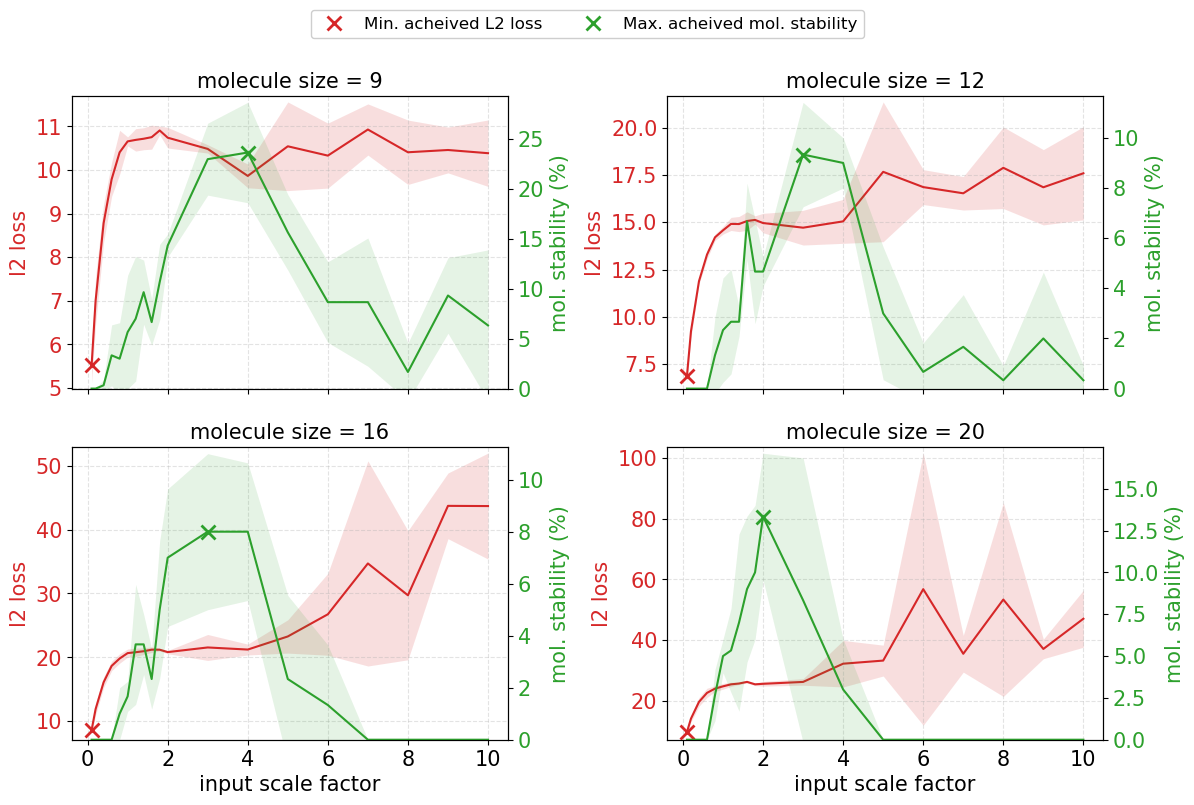

polynomial_2


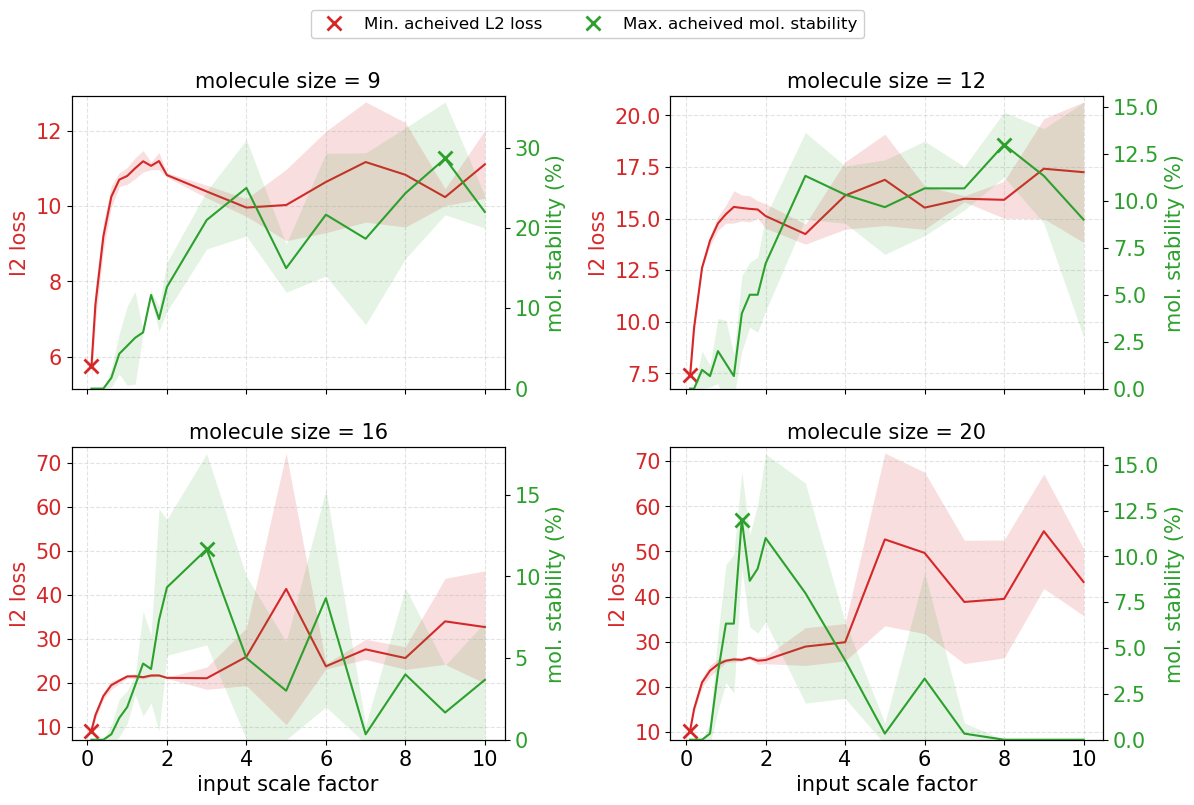

In [47]:
# load data
df = pd.read_csv("input_scaling_evaluation_log_rq1.csv")  # update path if needed

# group and compute mean + std across seeds (or repeats)
grouped = (
    df.groupby(["filter_n_atoms", "input_scale_factor", "diffusion_noise_schedule"])
    .agg(
        mol_mean = ("mol_stable", "mean"),
        mol_std  = ("mol_stable", "std"),
        test_mean = ("test_l2", "mean"),
        test_std  = ("test_l2", "std"),
    )
    .reset_index()
)

# replace NaN std (single-sample groups) with 0 so shading works
grouped["mol_std"]  = grouped["mol_std"].fillna(0.0)
grouped["test_std"] = grouped["test_std"].fillna(0.0)

# derive min/max from means (expand later with std when plotting)
mol_min, mol_max   = grouped["mol_mean"].min(), grouped["mol_mean"].max()
test_min, test_max = grouped["test_mean"].min(), grouped["test_mean"].max()

noise_schedules = grouped["diffusion_noise_schedule"].unique()
filter_values = sorted(grouped["filter_n_atoms"].unique())

for noise_schedule, schedule_df in grouped.groupby("diffusion_noise_schedule"):
    print(noise_schedule)
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()

    for i, n_atoms in enumerate(filter_values):
        ax_left = axes[i]
        sub_df = schedule_df[schedule_df["filter_n_atoms"] == n_atoms].copy()
        sub_df = sub_df.sort_values("input_scale_factor").reset_index(drop=True)

        if sub_df.empty:
            ax_left.set_visible(False)
            continue

        x = sub_df["input_scale_factor"].values
        y_mol = sub_df["mol_mean"].values
        y_mol_std = sub_df["mol_std"].values
        y_test = sub_df["test_mean"].values
        y_test_std = sub_df["test_std"].values

        color_left = "tab:red"
        ax_left.set_title(f"molecule size = {n_atoms}")

        # Plot Test L2 (left axis) with shaded std
        ax_left.plot(x, y_test, linestyle='-', color=color_left, label="L2 Loss")
        ax_left.fill_between(x, y_test - y_test_std, y_test + y_test_std,
                             color=color_left, alpha=0.15, linewidth=0)
        ax_left.set_ylabel("l2 loss", color=color_left)
        ax_left.tick_params(axis='y', labelcolor=color_left)

        # expand ylim a bit to include shaded region
        y_test_lower = (y_test - y_test_std).min()
        y_test_upper = (y_test + y_test_std).max()
        pad = 0.02 * (y_test_upper - y_test_lower) if (y_test_upper - y_test_lower) != 0 else 0.1
        ax_left.set_ylim(y_test_lower - pad, y_test_upper + pad)

        ax_left.grid(True, linestyle='--', alpha=0.35)
        # mark best (min) L2
        try:
            idx_l2_best = int(np.nanargmin(y_test))
            ax_left.plot(x[idx_l2_best], y_test[idx_l2_best],
                         marker='x', markersize=10, markeredgewidth=2,
                         color=color_left, zorder=5, label="Min L2 Loss")
        except ValueError:
            pass

        # Right axis: molecule stability
        ax_right = ax_left.twinx()
        color_right = "tab:green"
        ax_right.plot(x, y_mol, linestyle='-', markersize=5, color=color_right, label="Molecule Stability")
        ax_right.fill_between(x, y_mol - y_mol_std, y_mol + y_mol_std,
                              color=color_right, alpha=0.12, linewidth=0)
        ax_right.set_ylabel("mol. stability (%)", color=color_right)
        ax_right.tick_params(axis='y', labelcolor=color_right)

        # expand mol y limits to include std region (with a small buffer)
        y_mol_lower = (y_mol - y_mol_std).min()
        y_mol_upper = (y_mol + y_mol_std).max()
        pad_m = 0.02 * (y_mol_upper - y_mol_lower) if (y_mol_upper - y_mol_lower) != 0 else 1.0
        ax_right.set_ylim(
            bottom=0,
        top=y_mol_upper + pad_m
        )
        # mark best (max) mol stability
        try:
            idx_mol_best = int(np.nanargmax(y_mol))
            ax_right.plot(x[idx_mol_best], y_mol[idx_mol_best],
                          marker='x', markersize=10, markeredgewidth=2,
                          color=color_right, zorder=5, label="Max mol_stable")
        except ValueError:
            pass

        if i >= 2:
            ax_left.set_xlabel("input scale factor")

    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # --- GLOBAL LEGEND FOR X AND O MARKERS ---
    legend_elements = [
        # best (min) L2 – red X
        Line2D([0], [0], marker='x', color='tab:red', linestyle='none',
               markersize=10, markeredgewidth=2,
               label="Min. acheived L2 loss"),
    
        # best (max) molecule stability – green X
        Line2D([0], [0], marker='x', color='tab:green', linestyle='none',
               markersize=10, markeredgewidth=2,
               label="Max. acheived mol. stability"),
    ]

    fig.legend(
        handles=legend_elements,
        loc="upper center",
        ncol=2,
        framealpha=0.95,
        bbox_to_anchor=(0.5, 1.02),
    )


    plt.show()


[ 9 12 16 20]
[4. 3. 3. 2.]
[ 9 10 11 12 13 14 15 16 17 18 19 20]
[3.84 3.68 3.52 3.36 3.2  3.04 2.88 2.72 2.56 2.4  2.24 2.08]


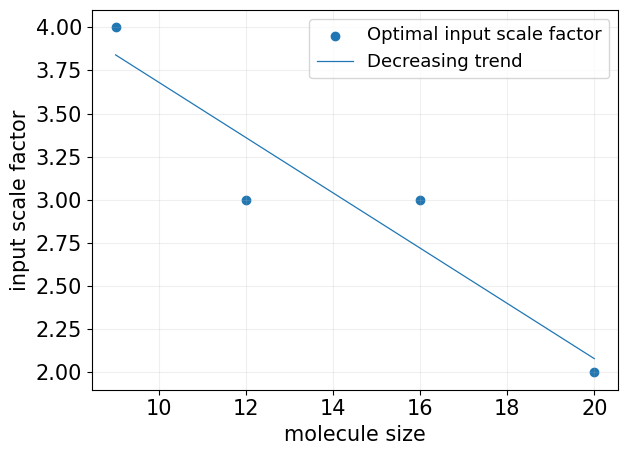

[ 9 12 16 20]
[9.  8.  3.  1.4]
[ 9 10 11 12 13 14 15 16 17 18 19 20]
[9.31709091 8.56145455 7.80581818 7.05018182 6.29454545 5.53890909
 4.78327273 4.02763636 3.272      2.51636364 1.76072727 1.00509091]


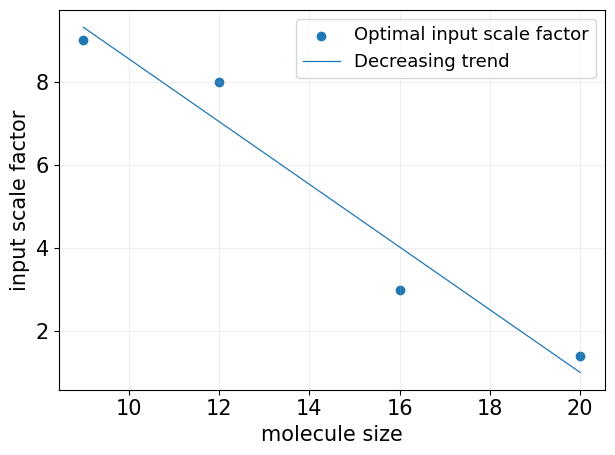

In [82]:
# Load CSV
df = pd.read_csv("input_scaling_evaluation_log_rq1.csv")

avg_df = (
    df.groupby(["diffusion_noise_schedule", "filter_n_atoms", "input_scale_factor"], as_index=False)
      .agg({"atm_stable": "mean", "mol_stable": "mean"})
)

# Find the best (highest mol_stable) input_scale_factor for each schedule + atom count
opt_df = avg_df.loc[
    avg_df.groupby(["diffusion_noise_schedule", "filter_n_atoms"])["mol_stable"].idxmax()
]

for schedule, sub in opt_df.groupby("diffusion_noise_schedule"):

    sub = sub.sort_values("filter_n_atoms")
    x = sub["filter_n_atoms"].values
    y = sub["input_scale_factor"].values
    print(x)
    print(y)

    coeffs = np.polyfit(x, y, 1)
    curve = np.poly1d(coeffs)

    x_fit = np.arange(9, 21, 1)
    y_fit = curve(x_fit)
    y_fit = np.clip(y_fit, min=0.1)

    print(x_fit)
    print(y_fit)

    plt.figure()
    plt.scatter(x, y, label="Optimal input scale factor")
    plt.plot(x_fit, y_fit, linestyle="-", label="Decreasing trend", linewidth=0.9)

    plt.xlabel("molecule size")
    plt.ylabel("input scale factor")
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
